In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('demo.csv')
display(df.head())

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,2025/01/01,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,2025-01-02,60.0,Rainy,W,Car,Night,0.0,Serious
2,2025-01-03,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,2025-01-04,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,2025-01-05,70.0,Rainy,W,Bike,Night,0.0,Serious


In [278]:
print(df.head())
print(df.info())
print(df.describe())

         Date  Speed Weather Road_Condition Vehicle_Type   Time  \
0  2025/01/01   45.0   Sunny            Dry         Bike    Day   
1  2025-01-02   60.0   Rainy              W          Car  Night   
2  2025-01-03   80.0   Foggy            Wet        Truck  Night   
3  2025-01-04   50.0   Sunny            Dry          Car    Day   
4  2025-01-05   70.0   Rainy              W         Bike  Night   

   Seatbelt/Helmet Severity  
0              1.0    Minor  
1              0.0  Serious  
2              NaN    Fatal  
3              1.0    Minor  
4              0.0  Serious  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             48 non-null     object 
 1   Speed            44 non-null     float64
 2   Weather          47 non-null     object 
 3   Road_Condition   48 non-null     object 
 4   Vehicle_Type     45 non-null     o

In [279]:
df.columns = df.columns.str.strip()

In [280]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )

#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")

df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [281]:
df.head()

,Date,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity
0,01/01/2025,45.0,Sunny,Dry,Bike,Day,1.0,Minor
1,02/01/2025,60.0,Rainy,W,Car,Night,0.0,Serious
2,03/01/2025,80.0,Foggy,Wet,Truck,Night,NaN,Fatal
3,04/01/2025,50.0,Sunny,Dry,Car,Day,1.0,Minor
4,05/01/2025,70.0,Rainy,W,Bike,Night,0.0,Serious


In [282]:
df['Road_Condition'] = df['Road_Condition'].replace({
    'W': 'Wet',
    'D': 'Dry'
})

In [283]:
print(df.isnull().sum())

Date                0
Speed               6
Weather             3
Road_Condition      2
Vehicle_Type        5
Time                6
Seatbelt/Helmet    12
Severity            0
dtype: int64


In [284]:
df['Speed'].fillna(df['Speed'].mean(), inplace=True)

/tmp/ipykernel_10268/2172377610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Speed'].fillna(df['Speed'].mean(), inplace=True)


In [285]:
for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time']:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_10268/2458391815.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [286]:
df['Seatbelt/Helmet'].fillna(0, inplace=True)

/tmp/ipykernel_10268/2001474051.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Seatbelt/Helmet'].fillna(0, inplace=True)


In [287]:
df.dropna(subset=['Severity'], inplace=True)

In [288]:
df.drop_duplicates(inplace=True)

In [289]:
df.isna().sum()

,0
Date,0
Speed,0
Weather,0
Road_Condition,0
Vehicle_Type,0
Time,0
Seatbelt/Helmet,0
Severity,0


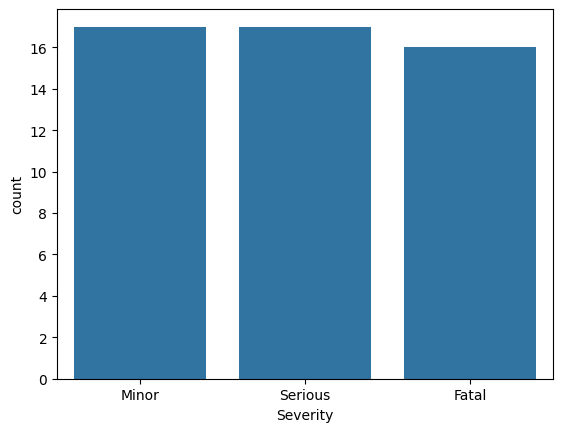

In [290]:
sns.countplot(x='Severity', data=df)
plt.show()

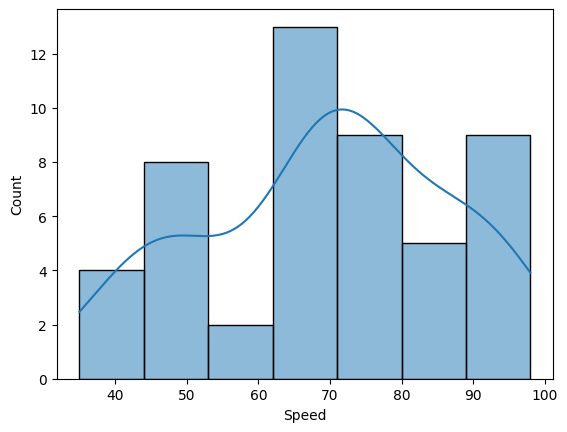

In [291]:
sns.histplot(df['Speed'], kde=True)
plt.show()

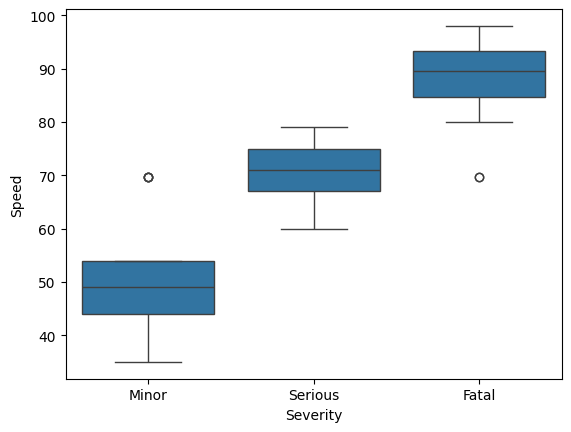

In [292]:
sns.boxplot(x='Severity', y='Speed', data=df)
plt.show()

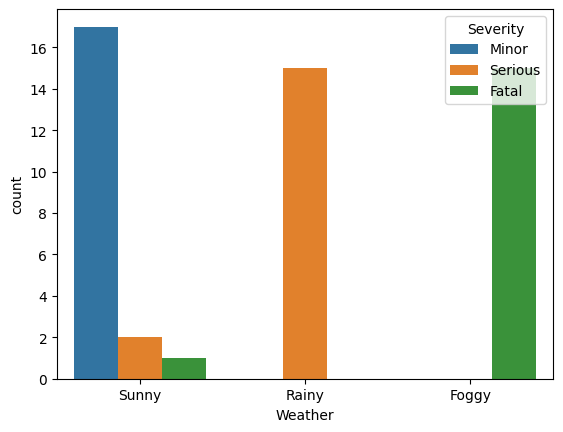

In [293]:
sns.countplot(x='Weather', hue='Severity', data=df)
plt.show()

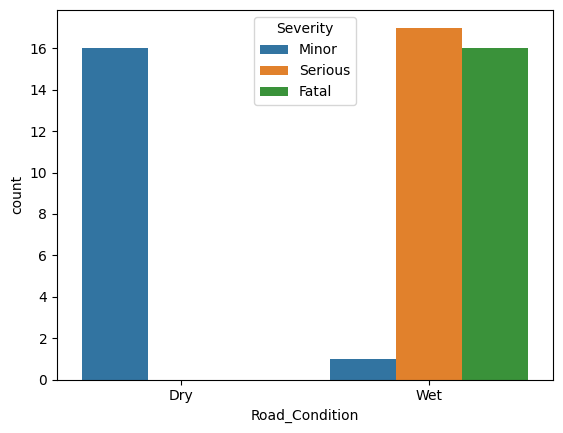

In [294]:
sns.countplot(x='Road_Condition', hue='Severity', data=df)
plt.show()

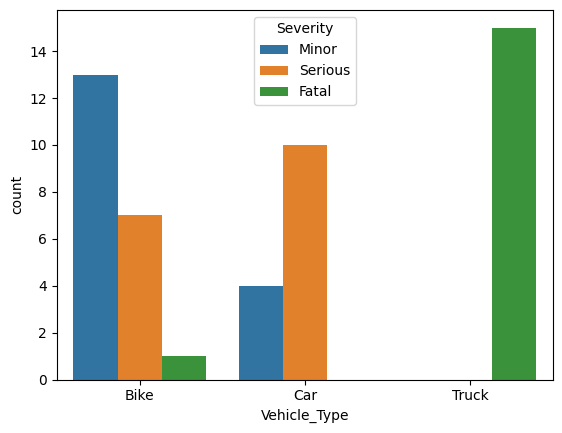

In [295]:
sns.countplot(x='Vehicle_Type', hue='Severity', data=df)
plt.show()

In [296]:
#adding additional Featues and Rows for better accuracy

new_rows = 100

# Create base data
new_data = pd.DataFrame({
    'Date': pd.date_range(start='2025-03-01', periods=new_rows, freq='D'),
    'Speed': np.random.randint(30, 100, new_rows),
    'Weather': np.random.choice(['Sunny', 'Rainy', 'Foggy'], new_rows),
    'Road_Condition': np.random.choice(['Dry', 'Wet'], new_rows),
    'Vehicle_Type': np.random.choice(['Bike', 'Car', 'Truck'], new_rows),
    'Time': np.random.choice(['Day', 'Night'], new_rows),
    'Seatbelt/Helmet': np.random.choice([0,1], new_rows),
    'Severity': np.random.choice(['Minor', 'Serious', 'Fatal'], new_rows),
    'Is_Night': np.random.choice([0,1], new_rows),
    'Speed_Category': np.random.choice(['Low', 'Medium', 'High'], new_rows),
    'Safety': np.random.choice(['Safe', 'Unsafe'], new_rows)
})


In [297]:
new_data['Is_Night'] = new_data['Time'].apply(lambda x: 1 if x == 'Night' else 0)
df['Is_Night'] = df['Time'].apply(lambda x: 1 if x == 'Night' else 0)

In [298]:
def speed_category(speed):
    if speed < 50:
        return "Low"
    elif speed < 80:
        return "Medium"
    else:
        return "High"

new_data['Speed_Category'] = new_data['Speed'].apply(speed_category)
df['Speed_Category'] = df['Speed'].apply(speed_category)

In [299]:
new_data['Safety'] = new_data['Seatbelt/Helmet'].apply(
    lambda x: "Safe" if x == 1 else "Unsafe"
)
df['Safety'] = df['Seatbelt/Helmet'].apply(
    lambda x: "Safe" if x == 1 else "Unsafe"
)

In [300]:
def assign_severity(row):
    if row['Speed'] > 85 and row['Road_Condition'] == 'Wet':
        return 'Fatal'
    elif row['Speed'] > 65:
        return 'Serious'
    else:
        return 'Minor'
new_data['Severity'] = new_data.apply(assign_severity, axis=1)
df['Severity'] = df.apply(assign_severity, axis=1)

In [301]:
df = pd.concat([df, new_data], ignore_index=True)

In [302]:
df['Date'] = pd.to_datetime(df['Date'],format='mixed',dayfirst=True,errors='coerce' )

#Convert to desired format (DD/MM/YYYY)
df['Date'] = df['Date'].dt.strftime("%d/%m/%Y")

df['Date'] = df['Date'].fillna(df['Date'].mode()[0])

In [303]:
df.isna().sum()

,0
Date,0
Speed,0
Weather,0
Road_Condition,0
Vehicle_Type,0
Time,0
Seatbelt/Helmet,0
Severity,0
Is_Night,0
Speed_Category,0


In [304]:
df.to_csv("improved_accident_data.csv", index=False)

In [305]:
df = df.drop('Date', axis=1)

In [306]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in ['Weather', 'Road_Condition', 'Vehicle_Type', 'Time', 'Severity', 'Speed_Category', 'Safety']:
    df[col] = df[col].astype(str) # Ensure all values are strings before encoding
    df[col] = encoder.fit_transform(df[col])

display(df.head())

,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Speed_Category,Safety
0,45.0,2,0,0,0,1.0,1,0,1,0
1,60.0,1,1,1,1,0.0,1,1,2,1
2,80.0,0,1,2,1,0.0,2,1,0,1
3,50.0,2,0,1,0,1.0,1,0,2,0
4,70.0,1,1,0,1,0.0,2,1,2,1


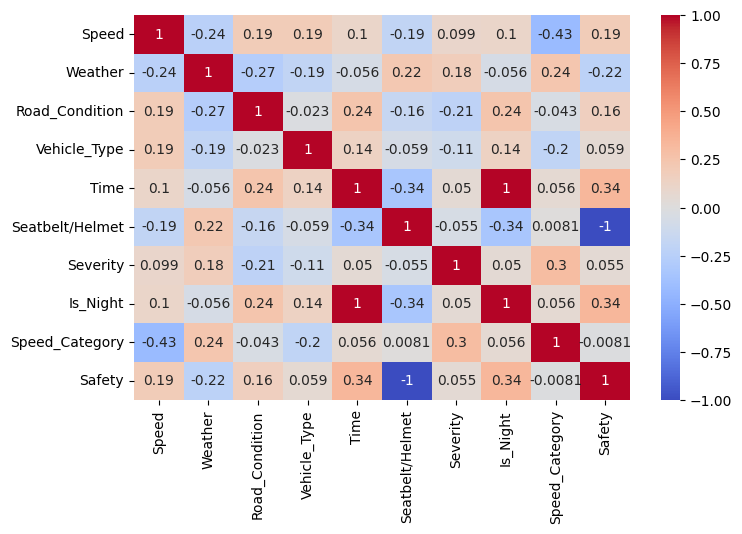

In [307]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [308]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Speed', 'Seatbelt/Helmet']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [309]:
df.head()

,Speed,Weather,Road_Condition,Vehicle_Type,Time,Seatbelt/Helmet,Severity,Is_Night,Speed_Category,Safety
0,-1.013959,2,0,0,0,1.175139,1,0,1,0
1,-0.247017,1,1,1,1,-0.850963,1,1,2,1
2,0.775572,0,1,2,1,-0.850963,2,1,0,1
3,-0.758312,2,0,1,0,1.175139,1,0,2,0
4,0.264277,1,1,0,1,-0.850963,2,1,2,1
